In [1]:
import pandas as pd
import numpy as np

from mpl_toolkits.axes_grid1.inset_locator import inset_axes # inset

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import seaborn as sns

# qqplot
import statsmodels.api as sm
import pylab as py

from scipy.stats import mannwhitneyu,wilcoxon,spearmanr,ttest_ind
from scipy.stats import sem

In [2]:
import sys
sys.path.append('/Users/dbao/Downloads/research/rc_scripts/submission/analysis/')

from process_helper import *
from plot_helper import *
save_mode = ".pdf"
font_size = 8

In [3]:
%load_ext rpy2.ipython

from rpy2.robjects.packages import importr
# import R's "base" package
lme4 = importr('lme4')
mass = importr('MASS')
rcompanion = importr('rcompanion')

/Users/dbao/opt/anaconda3/envs/road/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:14: FutureWarning: pandas.core.index is deprecated and will be removed in a future version. The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


# Load data

In [4]:
home_dir = '/Users/dbao/Library/CloudStorage/GoogleDrive-sherrydbao@gmail.com/My Drive/road_construction_data/data/2022_online/'
data_dir = home_dir + 'R_analysis_data/'
out_dir = home_dir + 'figures/figures_final/'
out_dir2 = home_dir + 'stat_model/final/'

In [5]:
data_choice_level = pd.read_csv(data_dir +  'choice_level/choicelevel_data.csv') # first column is index  
data_choice_level = data_choice_level.rename(columns={'Unnamed: 0':'index_copy'})
data_choice_level = df_choice_add_features(data_choice_level)
sc_data_choice_level = data_choice_level[data_choice_level['condition']==1].reset_index(drop=True) 

In [6]:
data_puzzle_level = pd.read_csv(data_dir +  'data.csv') # first column is subject
data_puzzle_level = df_map_add_features(data_puzzle_level, data_choice_level)

In [7]:
single_condition_data = data_puzzle_level[data_puzzle_level['condition']==1].copy()
single_condition_data = single_condition_data.reset_index(drop=True)

## select the data where first undo is possible

In [8]:
undo_data, cutoff_budget, cutoff_budgetchange, cutoff_withinreachchange, cutoff_efficiency= df_subset_undo(sc_data_choice_level)
undo_data = undo_data.merge(single_condition_data[["subjects","puzzleID", "RT1", "RT_branching", "RTsubmit"]], on=["subjects","puzzleID"], how = "left")
undo_data = undo_data.merge(data_puzzle_level.loc[data_puzzle_level.condition==0, ["subjects","puzzleID", "TT"]], on=["subjects","puzzleID"], how = "left")
only_undo_df = undo_data.loc[(undo_data.single_undo == 1)|(undo_data.sequential_undo == 1)] # for calculating proportions of different types of undo

In [9]:
%%R -i undo_data,data_dir

standardize <- function(x) {
    return (x - min(x))/(max(x) - min(x))
}
undo_data$subjects <- as.factor(undo_data[,"subjects"])
undo_data$puzzleID <- as.factor(undo_data[,"puzzleID"])
undo_data$checkEnd <- as.factor(undo_data[,"checkEnd"])
# undo_data$efficiency_new <- undo_data[,"efficiency"]^(0.3)
undo_data$N_more_new <- scale(undo_data[,"N_more"])
undo_data$currNumCities_new <- scale(undo_data[,"currNumCities"])
undo_data$leftover_new <- scale(undo_data[,"leftover"])
undo_data$leftover_currNumCities <- undo_data[,"currNumCities_new"]+undo_data[,"leftover_new"]
undo_data$within_reach_new <- scale(sqrt(undo_data[,"within_reach"]))
undo_data$budget_change_new <- scale(undo_data[,"budget_change"])
undo_data$within_reach_change_new <- scale(undo_data[,"within_reach_change"])

# save undo_data
write.csv(undo_data, file = paste0(data_dir, "statsdata_undo_data.csv"), row.names = F)

# Figure 3a: Undo - suboptimality

In [10]:
# undo or move
undo_noerror_nonterminal = undo_data.loc[(undo_data.cumulative_error == 0)&(undo_data.checkEnd == 0), :]
undo_error_nonterminal = undo_data.loc[(undo_data.cumulative_error != 0)&(undo_data.checkEnd == 0), :]
undo_nonterminal = undo_data.loc[(undo_data.checkEnd == 0), :]

undo_noerror_avg_nonterminal = undo_noerror_nonterminal.groupby("subjects")['undo'].mean()
undo_error_avg_nonterminal = undo_error_nonterminal.groupby("subjects")['undo'].mean()
undo_avg_nonterminal = undo_nonterminal.groupby("subjects")['undo'].mean()
noundo_error_avg_nonterminal = (undo_error_nonterminal['undo'] == 0).groupby(undo_error_nonterminal["subjects"]).mean()
# get standard error and mean
print(undo_noerror_avg_nonterminal.mean(), undo_noerror_avg_nonterminal.sem())
print(undo_error_avg_nonterminal.mean(), undo_error_avg_nonterminal.sem())
print(noundo_error_avg_nonterminal.mean(), noundo_error_avg_nonterminal.sem())
print(undo_avg_nonterminal.mean(), undo_avg_nonterminal.sem())

# print(len(undo_noerror_avg))
# print(len(undo_error_avg))

0.006471973973606115 0.0008637041565077797
0.019928661548769773 0.0021134599926873575
0.9800713384512301 0.0021134599926873584
0.011625244033322591 0.0011982028061208012


In [11]:
# undo or submit
undo_noerror_terminal = undo_data.loc[(undo_data.cumulative_error == 0)&(undo_data.checkEnd == 1), :]
undo_error_terminal = undo_data.loc[(undo_data.cumulative_error != 0)&(undo_data.checkEnd == 1), :]
undo_terminal = undo_data.loc[(undo_data.checkEnd == 1), :]

undo_noerror_avg_terminal = undo_noerror_terminal.groupby("subjects")['undo'].mean()
undo_error_avg_terminal = undo_error_terminal.groupby("subjects")['undo'].mean()
undo_avg_terminal = undo_terminal.groupby("subjects")['undo'].mean()
noundo_error_avg_terminal = (undo_error_terminal['undo'] == 0).groupby(undo_error_terminal["subjects"]).mean()
# get standard error and mean
print(undo_noerror_avg_terminal.mean(), undo_noerror_avg_terminal.sem())
print(undo_error_avg_terminal.mean(), undo_error_avg_terminal.sem())
print(noundo_error_avg_terminal.mean(), noundo_error_avg_terminal.sem())
print(undo_avg_terminal.mean(), undo_avg_terminal.sem())

0.13511623178939505 0.02335556301250257
0.38625832822720463 0.030653225347983388
0.6137416717727955 0.03065322534798338
0.2731364711743016 0.025235341613865554


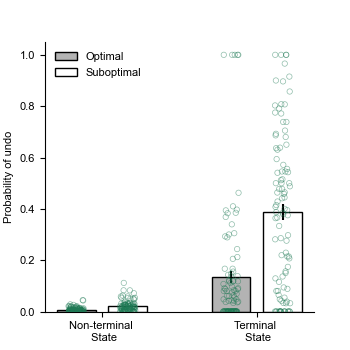

In [12]:
# This uses all undo
# plot in a scatter plot
%matplotlib widget
plt.rcParams.update({'font.size': font_size})
fig, axs = plt.subplots(1, 1)
# Set figure size to be square
fig.set_size_inches(3.5, 3.5)

positions = [1, 1.8, 3.4, 4.2]

# Overlay individual dots as open circles
np.random.seed(42)  # For reproducible jitter
data_arrays = [undo_noerror_avg_nonterminal, undo_error_avg_nonterminal, 
               undo_noerror_avg_terminal, undo_error_avg_terminal]

for pos, data in zip(positions, data_arrays):
    jitter = np.random.uniform(-0.12, 0.12, len(data))
    axs.scatter(pos + jitter, data, facecolors='none', edgecolors='#1F7A55', 
                s=15, alpha=0.5, zorder=3, linewidths=0.5)

mean_values = [undo_noerror_avg_nonterminal.mean(), 
                undo_error_avg_nonterminal.mean(), 
                undo_noerror_avg_terminal.mean(), 
                undo_error_avg_terminal.mean()]

bars = axs.bar(positions,
               mean_values,
               width=0.6,
               color=[(.7, .7, .7), 'w', (.7, .7, .7), 'w'],
               edgecolor='k')

# add standard error
errs = axs.errorbar(positions,
                    mean_values,
                    yerr=[undo_noerror_avg_nonterminal.sem(), 
                    undo_error_avg_nonterminal.sem(), 
                    undo_noerror_avg_terminal.sem(), 
                    undo_error_avg_terminal.sem()],
                    fmt='none',  # No connecting line
                    ecolor='k')  # Error bar color
                
axs.set_ylabel('Probability of undo')
# axs.set_yticks(np.arange(0,0.6,0.1))
# axs.set_xticks([1,1.5, 2,3,3.5, 4])
axs.set_xticks([1.4, 3.8])

axs.set_xticklabels(labels = [
                              'Non-terminal \n State',
            
                              'Terminal \n State'
                    ])

# Add legend
axs.legend((bars[0], bars[1]), ('Optimal', 'Suboptimal'), 
           loc='upper left', frameon=False, fontsize=font_size)

# set ratio to be 1:1
axs.set_aspect(1/axs.get_data_ratio())
fig.savefig(out_dir + 'undo_corrective'+save_mode, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
%%R
# eq:stats_undo_optimality
undo_data$suboptimal_state <- undo_data$cumulative_error > 0
model_undo = lme4::glmer(undo ~  1 + suboptimal_state  + (1 |subjects) + (1|puzzleID),
                                  data = undo_data[undo_data$checkEnd == 0,], family = "binomial")
model_undo_full = lme4::glmer(undo ~  1 + suboptimal_state  + (1+suboptimal_state|subjects) + (1+suboptimal_state|puzzleID),
                                  data = undo_data[undo_data$checkEnd == 0,], family = "binomial")  
# save(model_undo, undo_data, file=file.path(out_dir2, file=paste("model_undo_cumulative_error.RData", sep="")))
summary(model_undo)
summary(model_undo_full)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: undo ~ 1 + suboptimal_state + (1 + suboptimal_state | subjects) +  
    (1 + suboptimal_state | puzzleID)
   Data: undo_data[undo_data$checkEnd == 0, ]

     AIC      BIC   logLik deviance df.resid 
  5550.3   5619.2  -2767.2   5534.3    40812 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.4657 -0.1282 -0.0893 -0.0630 20.8873 

Random effects:
 Groups   Name                 Variance Std.Dev. Corr 
 subjects (Intercept)          0.8641   0.9296        
          suboptimal_stateTRUE 0.1848   0.4299   -0.38
 puzzleID (Intercept)          0.2230   0.4723        
          suboptimal_stateTRUE 0.1674   0.4092   -0.59
Number of obs: 40820, groups:  subjects, 100; puzzleID, 46

Fixed effects:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           -5.5538     0.1745 -31.823  < 2e-16 ***
suboptimal_stateTRUE   1.3300 

In [29]:
%%R
model_undo = lme4::glmer(undo ~  1 + suboptimal_state  + (1 |subjects) + (1|puzzleID),
                                  data = undo_data[undo_data$checkEnd == 1,], family = "binomial")
model_undo_full = lme4::glmer(undo ~  1 + suboptimal_state  + (1+suboptimal_state|subjects) + (1|puzzleID),
                                  data = undo_data[undo_data$checkEnd == 1,], family = "binomial")
# save(model_undo, undo_data, file=file.path(out_dir2, file=paste("model_undo_cumulative_error.RData", sep="")))
summary(model_undo)
summary(model_undo_full)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: undo ~ 1 + suboptimal_state + (1 + suboptimal_state | subjects) +  
    (1 | puzzleID)
   Data: undo_data[undo_data$checkEnd == 1, ]

     AIC      BIC   logLik deviance df.resid 
  5295.4   5336.0  -2641.7   5283.4     6404 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-6.7457 -0.4376 -0.1500  0.3932  7.9297 

Random effects:
 Groups   Name                 Variance Std.Dev. Corr 
 subjects (Intercept)          6.80729  2.6091        
          suboptimal_stateTRUE 0.05026  0.2242   -0.92
 puzzleID (Intercept)          0.51440  0.7172        
Number of obs: 6410, groups:  subjects, 100; puzzleID, 46

Fixed effects:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           -3.7551     0.3307  -11.36   <2e-16 ***
suboptimal_stateTRUE   2.9422     0.1714   17.16   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01

# Figure 4a: Undo - Error magnitude

In [20]:
undo_data_end_avg = undo_data.groupby(["subjects","cumulative_error", "checkEnd"])["undo"].mean().reset_index()
undo_data_end_avg.groupby(["cumulative_error", "checkEnd"])["undo"].count()

cumulative_error  checkEnd
0                 0           100
                  1            99
1                 0           100
                  1            99
2                 0           100
                  1           100
3                 0            78
                  1            79
4                 0            37
                  1            37
5                 0             7
                  1             7
6                 0             3
                  1             1
8                 1             1
Name: undo, dtype: int64

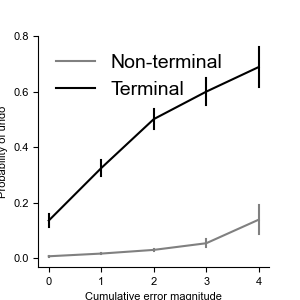

In [21]:
# This uses all undo
%matplotlib widget
fig, axs = plt.subplots(1, 1)
fig.set_size_inches(3, 3)
plt.rcParams.update({'font.size': font_size})

# multiple line plot    
sns.lineplot(x='cumulative_error', y='undo', 
             data = undo_data_end_avg[undo_data_end_avg.cumulative_error<5], 
             hue = "checkEnd",
             palette = ["grey","k"],
             err_style = "bars",
             errorbar = "se")

plt.legend(labels=['Non-terminal','Terminal'], loc='upper left', fontsize=14)

axs.set_xticks([0,1,2,3,4])
axs.set_yticks(np.arange(0,0.9,0.2))
# axs.set_ylim(0,0.15)

axs.set(xlabel='Cumulative error magnitude', ylabel='Probability of undo')
axs.set_aspect(1/axs.get_data_ratio())
plt.show()
fig.savefig(out_dir+'undo_terminal_cumulative_error'+save_mode, dpi=300, bbox_inches='tight')

# Undo - State Features

## number of cities

#### optimality, only terminal

In [92]:
firstUndo_sub = undo_data[undo_data.checkEnd==1].groupby(['subjects','currNumCities','suboptimal_state'])['undo'].mean().reset_index()
# firstUndo_sub.groupby(['currNumCities','error'])['firstUndo'].count()

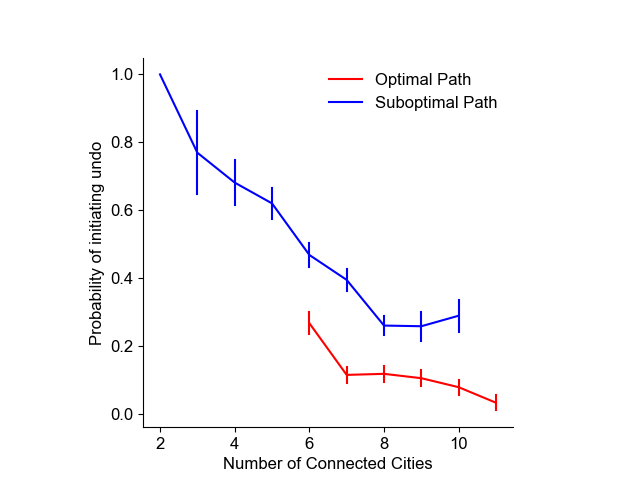

In [93]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.lineplot(x='currNumCities', y='undo', 
             data = firstUndo_sub,
             hue = 'suboptimal_state',
             palette = ['red','blue'],
             err_style = "bars",
             errorbar = "se")
# add manual legend
plt.legend(labels=['Optimal Path','Suboptimal Path'], loc='upper right')
axs.set(xlabel='Number of Connected Cities', ylabel='Probability of initiating undo')
axs.set_aspect(1/axs.get_data_ratio())
# fig.savefig(out_dir+'undo_currNumCities.png', dpi=300, bbox_inches='tight')
plt.show()

### terminal 

In [95]:
firstUndo_sub = undo_data.groupby(['subjects','currNumCities',"checkEnd"])['firstUndo'].mean().reset_index()
count_df = firstUndo_sub.groupby(["currNumCities","checkEnd"])['firstUndo'].count().reset_index()
firstUndo_sub = firstUndo_sub.merge(count_df, on = ["currNumCities","checkEnd"], how = "left", suffixes = ("","_count"))
# firstUndo_sub = firstUndo_sub[firstUndo_sub['firstUndo_count'] > 30]

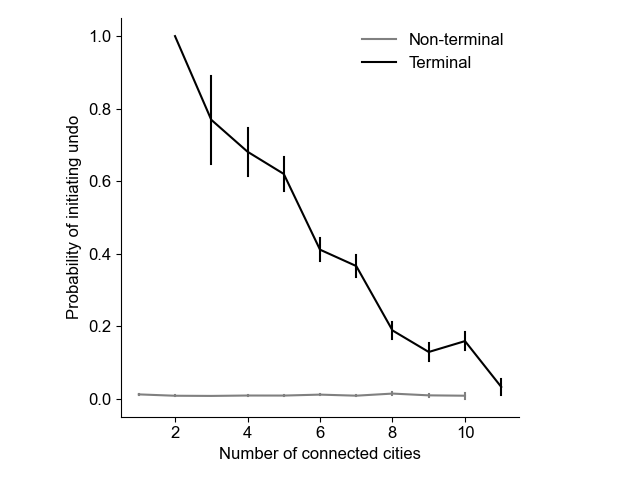

In [98]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.lineplot(x='currNumCities', y='firstUndo', 
             hue = "checkEnd", 
             data = firstUndo_sub,
             errorbar = "se",
             err_style = "bars",
             palette = ['grey','k']
             )
axs.set(xlabel='Number of connected cities', 
        ylabel='Probability of initiating undo')
# set legend title
axs.legend(labels=['Non-terminal','Terminal'], frameon=False, loc='upper right')
axs.set_aspect(1/axs.get_data_ratio())
plt.tight_layout()
fig.savefig(out_dir+'undo_step_terminal.png', dpi=300, bbox_inches='tight')

### *Across N_more

In [22]:
firstUndo_sub = undo_data.groupby(['subjects','N_more'])['firstUndo'].mean().reset_index()

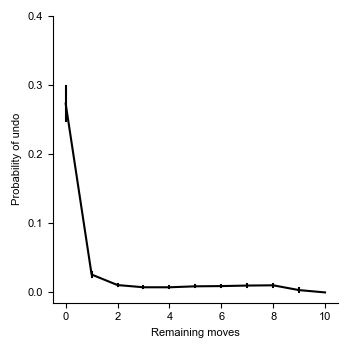

In [23]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)
fig.set_size_inches(3.5, 3.5)
plt.rcParams.update({'font.size': font_size})

# multiple line plot    
sns.lineplot(x='N_more', y='firstUndo', 
        #      hue = "allMAS", 
             color = 'k',
             data = firstUndo_sub,
             errorbar = "se",
             err_style = "bars"
             #palette = ['red','blue']
             )
axs.set_xticks(range(0,11,2))

axs.set_yticks(np.arange(0,0.5,0.1))
# axs.set_ylim([0,0.2])
axs.set(xlabel='Remaining moves', 
        ylabel='Probability of undo')
plt.tight_layout()
fig.savefig(out_dir+'undo_nmore'+save_mode, dpi=300, bbox_inches='tight')

### Puzzle MAS

In [44]:
firstUndo_sub = undo_data.groupby(['subjects','allMAS','checkEnd'])['firstUndo'].mean().reset_index()
# firstUndo_sub.groupby(['allMAS','checkEnd'])['firstUndo'].count()

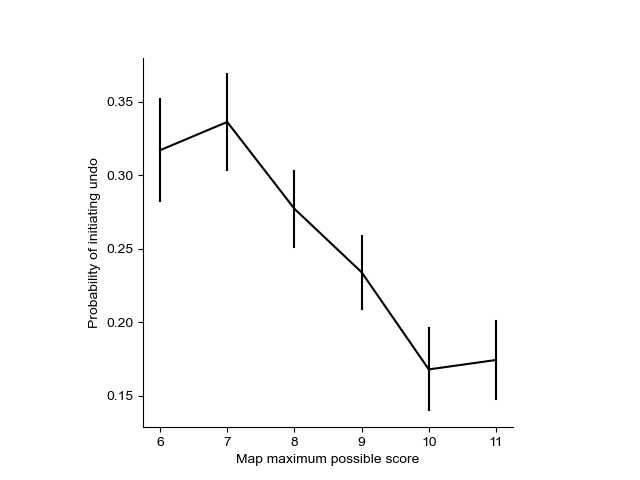

In [46]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.lineplot(x='allMAS', y='firstUndo', 
             data = firstUndo_sub[firstUndo_sub.checkEnd==1], 
             hue = 'checkEnd',
             palette = ['k'],
             err_style = "bars",
             errorbar = "se")
# add manual legend
# axs.legend(labels=['Non-terminal','Terminal'], frameon=False, loc='upper right')
# hide legend
axs.get_legend().remove()
axs.set(xlabel='Map maximum possible score', ylabel='Probability of initiating undo')
axs.set_aspect(1/axs.get_data_ratio())
fig.savefig(out_dir+'undo_MAS.png', dpi=300, bbox_inches='tight')
plt.show()

### proportion, sequential undo - terminal/non-terminal

In [21]:
sequentialUndo_sub = only_undo_df.groupby(['subjects','checkEnd'])['sequential_undo'].mean().reset_index()

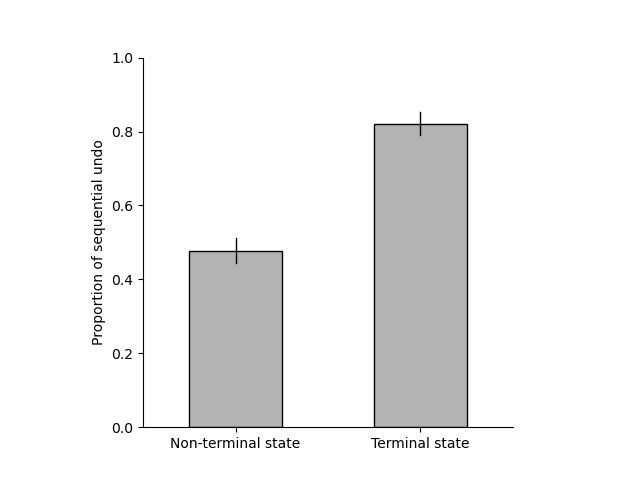

In [22]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.barplot(x='checkEnd', y='sequential_undo', 
            data = sequentialUndo_sub, 
            color= [0.7,0.7,0.7],
            edgecolor = ['k','k','k'],
            width=.5,
            linewidth=1,
            errcolor = 'k',
            errwidth = 1,
            errorbar = "se")

axs.set_xticklabels(labels = [ "Non-terminal state" , "Terminal state"])#,fontsize=18

# # add text on the upper of each bar 
# for x, y, n in zip([0,1], sequentialUndo_sub.groupby(['checkEnd'])['sequential_undo'].mean(), n_sub.sequentialUndo):
#     axs.text(x, y+0.05, "N = " + str(n), ha='center', va='bottom', fontsize=12)

axs.set_yticks(np.linspace(0,1,6))
#sns.lineplot(x='severityOfErrors', y='sequentialUndo', data = sequentialUndo_sub, errorbar = "se")
axs.set(xlabel = '', ylabel='Proportion of sequential undo')
axs.set_aspect(1/axs.get_data_ratio(), adjustable='box')

fig.savefig(out_dir+'sequential_terminal.png', dpi=300, bbox_inches='tight')

In [23]:
stat1, p1 = mannwhitneyu(np.array(sequentialUndo_sub.loc[(sequentialUndo_sub.checkEnd==1),'sequential_undo']), 
                     np.array(sequentialUndo_sub.loc[(sequentialUndo_sub.checkEnd==0),'sequential_undo'])) 
# axs.set_title(r"$p = {0:s}$".format(as_si(p1,1)))
print(stat1, p1)

5423.0 2.194581026983643e-12


## Remaining budget

In [105]:
firstUndo_sub = undo_data.groupby(['subjects','leftover_bin', 'checkEnd'])['firstUndo'].mean().reset_index()
count_df = firstUndo_sub.groupby(['leftover_bin', 'checkEnd'])['firstUndo'].count()
# firstUndo_sub = firstUndo_sub.merge(count_df, on = ["leftover_bin","checkEnd"], how = "left", suffixes = ("","_count"))
# firstUndo_sub = firstUndo_sub[firstUndo_sub['firstUndo_count'] > 30]

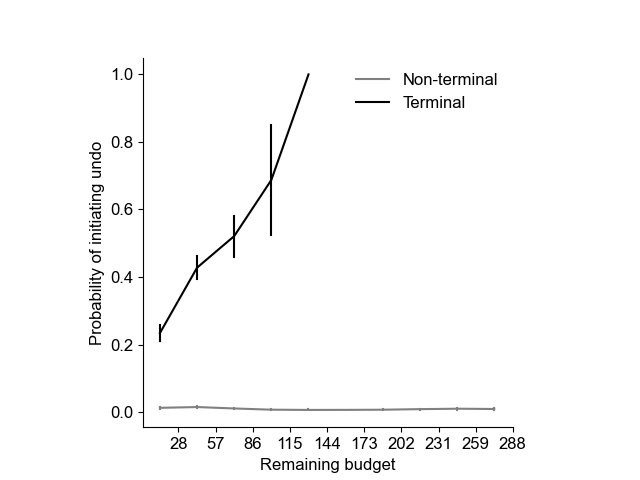

In [106]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.lineplot(x='leftover_bin', y='firstUndo', 
             data = firstUndo_sub,
             hue = 'checkEnd',
             palette = ['grey','k'],
             err_style = "bars",
             errorbar = "se")
# use cutoff to set x ticklabels
axs.set_xticks(np.arange(0.5, 10.5, 1))
axs.set_xticklabels(cutoff_budget[1:].astype(int))
axs.legend(labels=['Non-terminal','Terminal'], frameon=False, loc='upper right')
axs.set(xlabel='Remaining budget', ylabel='Probability of initiating undo')
axs.set_aspect(1/axs.get_data_ratio())
fig.savefig(out_dir+'undo_budget.png', dpi=300, bbox_inches='tight')
plt.show()

## Efficiency

## Budget change

In [30]:
firstUndo_sub = undo_data.groupby(['subjects','budget_change_bin', 'N_more'])['firstUndo'].mean().reset_index()
count_df = firstUndo_sub.groupby(['budget_change_bin', 'N_more'])['firstUndo'].count()
# firstUndo_sub = firstUndo_sub.merge(count_df, on = ["budget_change_bin","checkEnd"], how = "left", suffixes = ("","_count"))
# firstUndo_sub = firstUndo_sub[firstUndo_sub['firstUndo_count'] > 30]

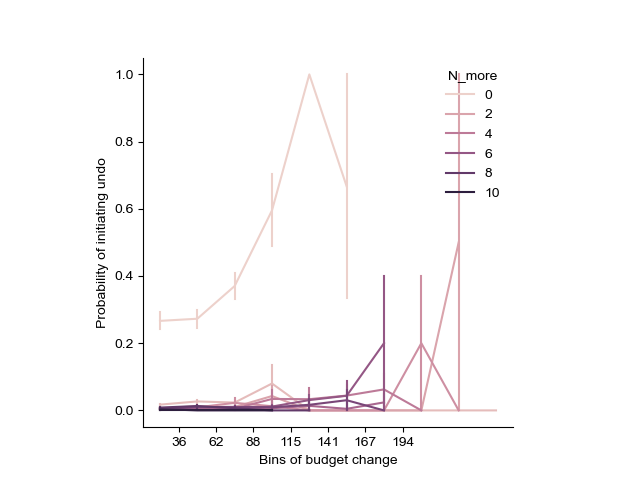

In [33]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot    
sns.lineplot(x='budget_change_bin', y='firstUndo', 
             data = firstUndo_sub,
             hue = 'N_more',
            #  palette = ['grey','k'],
             err_style = "bars",
             errorbar = "se")
#sns.lineplot(x='severityOfErrors', y='sequentialUndo', data = sequentialUndo_sub, errorbar = "se")
# use cutoff to set x ticklabels
axs.set_xticks(np.arange(0.5, 7.5, 1))
axs.set_xticklabels(cutoff_budgetchange[1:8].astype(int))
# axs.legend(labels=['Non-terminal','Terminal'], frameon=False, loc='upper right')
axs.set(xlabel='Bins of budget change', ylabel='Probability of initiating undo')
axs.set_aspect(1/axs.get_data_ratio())
fig.savefig(out_dir+'undo_budgetchange_terminal.png', dpi=300, bbox_inches='tight')
plt.show()

## Within reach change

In [112]:
# plot undo across leftover_bin
firstUndo_sub = undo_data.groupby(['subjects','within_reach_change_bin','checkEnd'])['firstUndo'].mean().reset_index()
count_df = firstUndo_sub.groupby(['within_reach_change_bin', 'checkEnd'])['firstUndo'].count()
firstUndo_sub = firstUndo_sub.merge(count_df, on = ["within_reach_change_bin","checkEnd"], how = "left", suffixes = ("","_count"))
firstUndo_sub = firstUndo_sub[firstUndo_sub['firstUndo_count'] > 30]

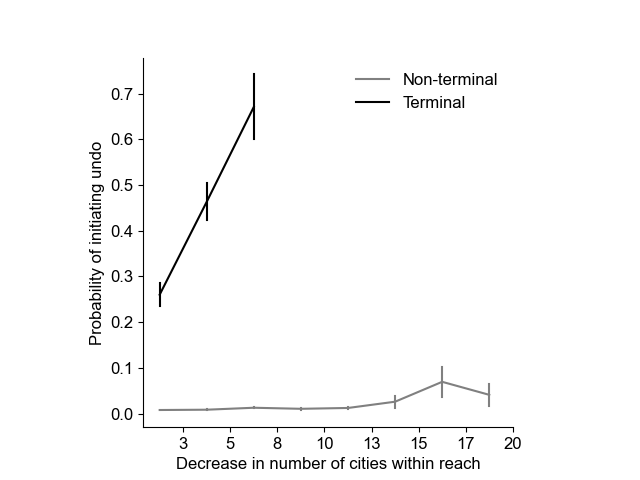

In [113]:
%matplotlib widget
fig, axs = plt.subplots(1, 1)

# multiple line plot
sns.lineplot(x='within_reach_change_bin', y='firstUndo', 
             data = firstUndo_sub,
             hue = "checkEnd",
             palette = ['grey','k'],
            #  color = 'k',
             err_style = "bars",
             errorbar = "se")
axs.set_xticks(np.arange(0.5, 8.5, 1))
axs.set_xticklabels(cutoff_withinreachchange[1:9].astype(int))
axs.legend(labels=['Non-terminal','Terminal'], frameon=False, loc='upper right')
axs.set(xlabel='Decrease in number of cities within reach', ylabel='Probability of initiating undo')
axs.set_aspect(1/axs.get_data_ratio())
plt.show()
fig.savefig(out_dir+'undo_withinreach_change_terminal.png', dpi=300, bbox_inches='tight')

# Figure 4c: undoRT

In [30]:
def organize_data(df, cond, type_):
    index_singleUndo = df.index[cond]
    df1 = df.loc[index_singleUndo, ['subjects', 'puzzleID', 'allMAS','RT', 'undo', ]]
    df1["N_more"] = df.loc[index_singleUndo-1, 'N_more'].values
    df1["currNumCities"] = df.loc[index_singleUndo-1, 'currNumCities'].values
    df1["severityOfErrors"] = df.loc[index_singleUndo-1, 'severityOfErrors'].values
    df1["cumulative_error"] = df.loc[index_singleUndo-1, 'cumulative_error'].values
    df1["scaled_N_more_bin"] = df.loc[index_singleUndo-1, 'scaled_N_more_bin'].values
    df1["checkEnd"] = df.loc[index_singleUndo-1, 'checkEnd'].values
    df1['type'] = type_
    return df1

df1 = organize_data(sc_data_choice_level, (sc_data_choice_level['firstUndo'] == 1) &(sc_data_choice_level['lastUndo'] == 1), "singleUndo")
df2 = organize_data(sc_data_choice_level, (sc_data_choice_level['firstUndo'] == 1) &(sc_data_choice_level['lastUndo'] != 1), "seqUndo")
df3 = organize_data(sc_data_choice_level, (sc_data_choice_level['undo'] == 0) & (sc_data_choice_level['RT'] != -1) & (sc_data_choice_level['submit'] == 0), "move")

df_all = pd.concat([df1, df2, df3])

In [31]:
%%R -i df_all,out_dir2
df_all$subjects <- as.factor(df_all[,"subjects"])
df_all$puzzleID <- as.factor(df_all[,"puzzleID"])
df_all$undo <- as.factor(df_all[,"undo"])
df_all$RT <- df_all$RT/1000
df_all$RT_log <- log(df_all$RT)

write.csv(df_all, file = paste0(data_dir, "statsdata_rt.csv"), row.names = F)

### cumulative error

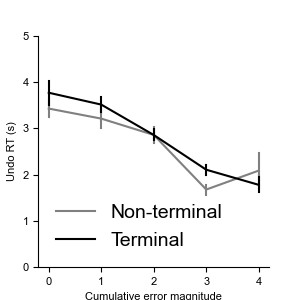

In [32]:
df = df_all[df_all.undo==1].groupby(['subjects','cumulative_error','checkEnd'])['RT'].mean().reset_index()
count_df = df.groupby(['cumulative_error','checkEnd'])['RT'].count().reset_index()
df = df.merge(count_df, on = ['cumulative_error'], how = "left", suffixes = ("","_count"))
df = df[df['RT_count'] > 10]
df['RT'] = df['RT']/1000

%matplotlib widget
fig, axs = plt.subplots(1, 1)
fig.set_size_inches(3, 3)
plt.rcParams.update({'font.size': font_size})
sns.lineplot(x='cumulative_error', y='RT', 
             hue = 'checkEnd',
             palette = ['grey','k'],
             data = df,
             err_style = "bars",
             errorbar = "se",
             color = 'k')
axs.set(xlabel='Cumulative error magnitude', ylabel='Undo RT (s)')
plt.legend(labels=['Non-terminal','Terminal'], loc='lower left', fontsize=14)
axs.set_yticks([0,1,2,3,4,5])
axs.set_xticks([0,1,2,3,4])
axs.set_aspect(1/axs.get_data_ratio())
plt.show()
fig.savefig(out_dir+'RT_cumulative_error_allstates'+save_mode, dpi=300, bbox_inches='tight')

### from terminal state: undo/submit

In [33]:
data_subset_before1undo = df_subset_1undo_submit(sc_data_choice_level)
state_undo_1undo = df_subset_1state(data_subset_before1undo, data_puzzle_level, single_condition_data, f"(firstUndo ==1)", 1)
state_notundo_1undo = df_subset_1state(data_subset_before1undo, data_puzzle_level, single_condition_data, f"(submit ==1)", 0)
state_df_1undo = pd.concat([state_undo_1undo,state_notundo_1undo])
state_df_1undo = state_df_1undo.reset_index(drop=True)

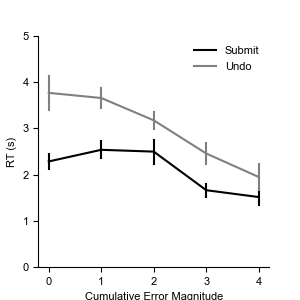

In [38]:
plot_df = state_df_1undo.groupby(['subjects','firstUndo','cumulative_error'])['RT'].mean().reset_index()
plot_df['RT'] = plot_df['RT']/1000
count_df = plot_df.groupby(['firstUndo','cumulative_error'])['RT'].count()
plot_df = plot_df.merge(count_df, on = ['firstUndo','cumulative_error'], how = "left", suffixes = ("","_count"))
plot_df = plot_df[plot_df['RT_count'] > 10]

# plot 
%matplotlib widget
fig, axs = plt.subplots(1, 1)
fig.set_size_inches(3, 3)
plt.rcParams.update({'font.size': font_size})

# multiple line plot
sns.lineplot(x='cumulative_error', y='RT', 
             data = plot_df,
             hue = 'firstUndo',
             palette = ["black", "grey"],
             err_style = "bars",
             errorbar = "se")
axs.set_yticks([0,1,2,3,4,5])
axs.set_xticks([0,1,2,3,4])
# add manual legend
plt.legend(labels=['Submit','Undo'], loc='upper right')
axs.set(xlabel='Cumulative Error Magnitude', ylabel='RT (s)')
axs.set_aspect(1/axs.get_data_ratio())
plt.show()
fig.savefig(out_dir+'undosubmit_RT_cumulative_error'+save_mode, dpi=300, bbox_inches='tight')
fig.savefig(out_dir+'undosubmit_RT_cumulative_error.png', dpi=300, bbox_inches='tight')

In [42]:
%%R -i state_df_1undo,out_dir2
state_df_1undo$subjects <- as.factor(state_df_1undo[,"subjects"])
state_df_1undo$puzzleID <- as.factor(state_df_1undo[,"puzzleID"])
state_df_1undo$firstUndo <- as.factor(state_df_1undo[,"firstUndo"])
levels(state_df_1undo$firstUndo) <- c("submit", "undo")
state_df_1undo$RT <- state_df_1undo$RT/1000
state_df_1undo <- state_df_1undo[state_df_1undo$RT <= 20,]
state_df_1undo$RT_log <- log(state_df_1undo$RT)

write.csv(state_df_1undo, file = paste0(data_dir, "statsdata_rt_terminal.csv"), row.names = F)